In [4]:
from turtledemo.chaos import plot

from torch.optim import lr_scheduler

"""
学习率从训练开始到结束都是不变的吗?

"""
from collections.abc import Iterable
from typing import override

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch import Tensor
import torch.optim.lr_scheduler as lr
import dnnlpy
import dnnlpy.optim as dopt
import matplotlib.pyplot as plt

dnnlpy.set_matplotlib_format('svg')

print('PyTorch Version:', torch.__version__)

PyTorch Version: 2.13.0+cpu


In [ ]:
"""
学习率调度器与优化器的关系
"""
model = nn.Linear(1, 1)
optimizer = optim.Adam(model.parameters(), lr=1)
scheduler = lr.CosineAnnealingLR(optimizer, T_max=100)

# for epoch in range(num_epochs):
#     for x, y in train_loader:
#         optimizer.zero_grad()
#         loss = compute_loss(model, x, y)
#         loss.backward()
#         optimizer.step()
#         scheduler.step()


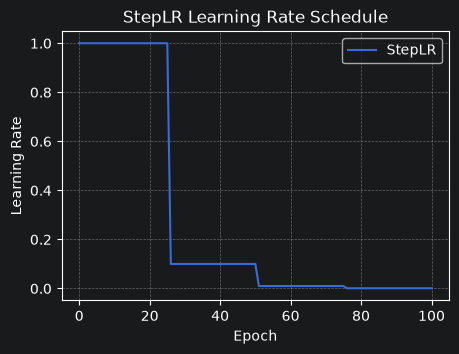

In [6]:
"""
stepLR 和multiStepLR:在固定位置降低学习率
"""
model = nn.Linear(1, 1)
optimizer = optim.Adam(model.parameters(), lr=1)
scheduler = lr.StepLR(optimizer, step_size=25, gamma=0.1)
dopt.plot_lr_schedule(optimizer, scheduler, num_steps=100)

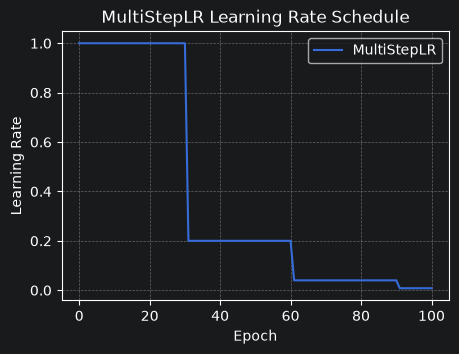

In [7]:
optimizer = optim.Adam(model.parameters(), lr=1)
scheduler = lr.MultiStepLR(optimizer, milestones=[30, 60, 90], gamma=0.2)
dopt.plot_lr_schedule(optimizer, scheduler, num_steps=100)

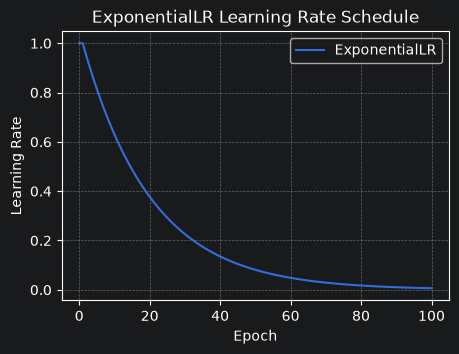

In [8]:
"""
ExponentialLR:持续指数衰减
"""

optimizer = optim.Adam(model.parameters(), lr=1)
scheduler = lr.ExponentialLR(optimizer, gamma=0.95)
dopt.plot_lr_schedule(optimizer, scheduler, num_steps=100)



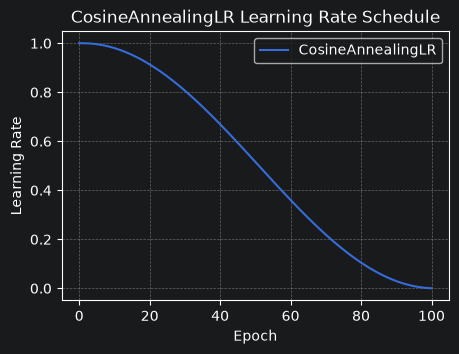

In [9]:
"""
CosineAnnealingLR:平滑地降到较小的学习率
"""
num_epochs = 100
optimizer = optim.Adam(model.parameters(), lr=1)
scheduler = lr.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
dopt.plot_lr_schedule(optimizer, scheduler, num_steps=num_epochs)

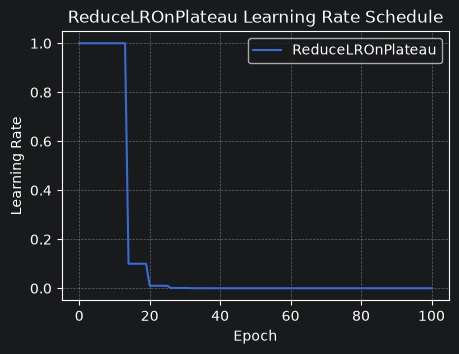

In [10]:
"""
ReduceLROnPlateau:指标停滞时在降低学习率
"""
import numpy as np

metric_values = np.random.rand(100)
optimizer = optim.Adam(model.parameters(), lr=1)
scheduler = lr.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
dopt.plot_lr_schedule(optimizer, scheduler, num_steps=100, metric_values=metric_values.tolist())

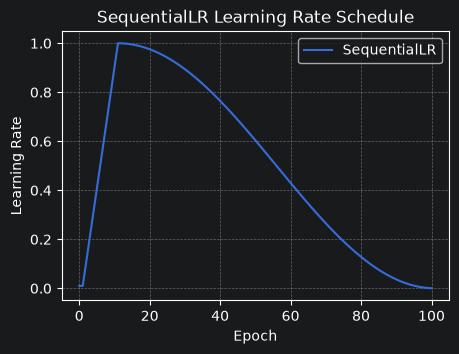

In [12]:
"""
Warmup: 训练开始时先慢慢升高学习率
"""

total_steps = 100
warmup_steps = 10

optimizer = optim.Adam(model.parameters(), lr=1)
warmup_scheduler = lr.LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
cosine_scheduler = lr.CosineAnnealingLR(optimizer, T_max=total_steps - warmup_steps, eta_min=1e-6)

scheduler = lr.SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_steps])
dopt.plot_lr_schedule(optimizer, scheduler, num_steps=total_steps)


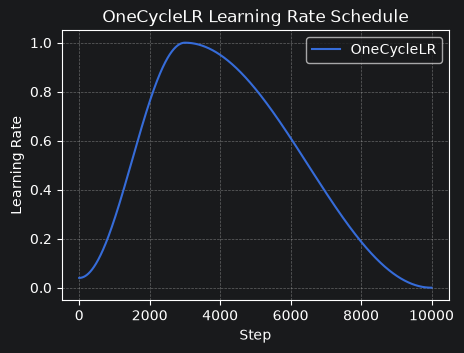

In [13]:
"""
OneCycleLR:先升后降的强Schedule
"""
num_epochs = 100
num_steps = 100 * num_epochs

optimizer = optim.Adam(model.parameters(), lr=1)
scheduler = lr.OneCycleLR(optimizer, max_lr=1, epochs=num_epochs, total_steps=num_steps)
dopt.plot_lr_schedule(optimizer, scheduler, num_steps, xlabel='Step')

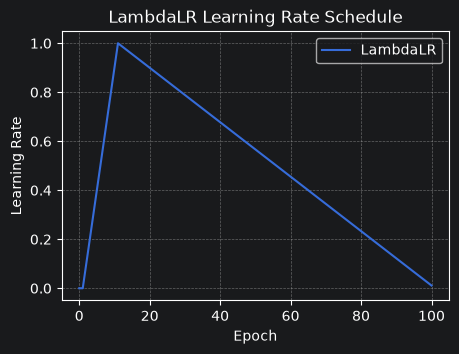

In [14]:
"""
LambdaLR:用函数定义schedule
"""

num_steps = 100
num_warmup_steps = 10


def lr_lamda(step: int) -> float:
    if step < num_warmup_steps:
        return step / max(1, num_warmup_steps)
    return max(0.0, (num_steps - step) / max(1, num_steps - num_warmup_steps))


optimizer = optim.Adam(model.parameters(), lr=1)
scheduler = lr.LambdaLR(optimizer, lr_lambda=lr_lamda)
dopt.plot_lr_schedule(optimizer, scheduler, num_steps)




In [ ]:
"""
PyTorch演示:训练循环中怎么使用Scheduler
"""

num_steps = 100

model = nn.Linear(1, 1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

scheduler = lr.CosineAnnealingLR(optimizer, T_max=num_steps)

for step in range(num_steps):
    model.train()
    for x, y in train_loader:
        optimizer.zero_grad()
        pre = model(x)
        loss = compute_loss(pred, y)
        loss.backward()
        optimizer.step()
    scheduler.step()

